# K-Nearest Neighbors (KNN) — Complete Notes

A complete walkthrough of KNN for **both classification and regression** with `scikit-learn` — manual distance calculations by hand first, then the Wine dataset (3-class chemical classification), a full hyperparameter reference, and the Diabetes dataset (disease-progression regression).

- **Part 0:** Distance Metrics — By Hand (Before Any Library)
- **Part 1:** KNN Classification with Scikit-Learn (Wine Dataset)
- **Part 2:** Real-World Uses & Hyperparameter Tuning
- **Part 3:** KNN Regression with Scikit-Learn (Diabetes Dataset)

---
## Part 0: Distance Metrics — By Hand (Before Any Library)

Before letting `scikit-learn` do the work, it's worth computing KNN's core operation — the **distance between two points** — by hand at least once. Every other part of this notebook (classification, regression, hyperparameter tuning) is built entirely on top of this one operation, repeated for every stored point, for every single prediction.

**Euclidean distance** (straight-line, "as the crow flies" — the default):

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

**Manhattan distance** (sum of absolute differences along each axis — "city block" distance):

$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

KNN-এর মূল কথা হলো — "তুমি তোমার সবচেয়ে কাছের প্রতিবেশীদের মতোই" (you are like your nearest neighbors) — কিন্তু "closest" বলার আগে দরকার একটা নির্দিষ্ট সংখ্যা, আর ঠিক সেই সংখ্যাটাই এই formula গুলো বের করে দেয়।

In [1]:
import numpy as np
import pandas as pd

# A tiny toy dataset: 6 students, 2 features.
# 'Result' is the CLASSIFICATION target, 'Exam_Score' is the REGRESSION target —
# same points, same distances, two different things to predict.
toy = pd.DataFrame({
    'Study_Hours':  [2, 3, 5, 7, 8, 1],
    'Attendance_%': [40, 50, 60, 80, 90, 30],
    'Result':       ['Fail', 'Fail', 'Pass', 'Pass', 'Pass', 'Fail'],
    'Exam_Score':   [35, 42, 58, 75, 82, 28],
})
toy.index = [f'P{i+1}' for i in range(len(toy))]
toy

,Study_Hours,Attendance_%,Result,Exam_Score
P1,2,40,Fail,35
P2,3,50,Fail,42
P3,5,60,Pass,58
P4,7,80,Pass,75
P5,8,90,Pass,82
P6,1,30,Fail,28


In [2]:
# A brand-new student we want to predict for:
query = np.array([6, 70])   # Study_Hours=6, Attendance_%=70

euclidean_dists = []
manhattan_dists = []
for name, row in toy.iterrows():
    point = row[['Study_Hours', 'Attendance_%']].to_numpy(dtype=float)
    euclidean_dists.append(np.sqrt(np.sum((point - query) ** 2)))   # d = sqrt(Σ(xi-yi)^2)
    manhattan_dists.append(np.sum(np.abs(point - query)))           # d = Σ|xi-yi|

toy['Euclidean_Dist'] = np.round(euclidean_dists, 2)
toy['Manhattan_Dist'] = np.round(manhattan_dists, 2)
toy.sort_values('Euclidean_Dist')

,Study_Hours,Attendance_%,Result,Exam_Score,Euclidean_Dist,Manhattan_Dist
P4,7,80,Pass,75,10.05,11.0
P3,5,60,Pass,58,10.05,11.0
P5,8,90,Pass,82,20.10,22.0
P2,3,50,Fail,42,20.22,23.0
P1,2,40,Fail,35,30.27,34.0
P6,1,30,Fail,28,40.31,45.0


In [3]:
k = 3
nearest = toy.sort_values('Euclidean_Dist').head(k)
print(nearest[['Study_Hours', 'Attendance_%', 'Result', 'Exam_Score', 'Euclidean_Dist']])

# --- Classification: majority vote among the k nearest labels ---
majority_vote = nearest['Result'].mode()[0]
print(f"\nk={k} nearest neighbors' labels: {list(nearest['Result'])}")
print(f"Majority vote  -> predicted Result     = {majority_vote}")

# --- Regression: mean of the k nearest numeric targets ---
avg_score = nearest['Exam_Score'].mean()
print(f"\nk={k} nearest neighbors' scores: {list(nearest['Exam_Score'])}")
print(f"Average (mean) -> predicted Exam_Score = {avg_score:.2f}")

    Study_Hours  Attendance_% Result  Exam_Score  Euclidean_Dist
P4            7            80   Pass          75           10.05
P3            5            60   Pass          58           10.05
P5            8            90   Pass          82           20.10

k=3 nearest neighbors' labels: ['Pass', 'Pass', 'Pass']
Majority vote  -> predicted Result     = Pass

k=3 nearest neighbors' scores: [75, 58, 82]
Average (mean) -> predicted Exam_Score = 71.67


The Euclidean-distance ranking puts **P3** and **P4** as the joint-closest students to the new query point (6 study hours, 70% attendance), followed by **P5**. Taking `k=3`:

- **Classification (majority vote)**: neighbors' labels are `Pass, Pass, Pass` → predicted `Result = Pass`.
- **Regression (mean)**: neighbors' scores average to `71.67` → predicted `Exam_Score ≈ 71.67`.

This *is* the entire KNN algorithm. Everything from here on — `KNeighborsClassifier`, `KNeighborsRegressor`, `StandardScaler`, choosing `k`, choosing a distance metric — exists only to do this same sort-and-aggregate operation correctly, efficiently, and at scale on real datasets. Notice also that Manhattan distance (`Manhattan_Dist` column above) ranks these same six points in the same order here — the two metrics don't always agree, but on this toy example they do.

### Bonus: Weighted Voting (`weights='distance'`) — by Hand

Instead of every neighbor getting an equal vote, `weights='distance'` gives each neighbor a vote of `1 / distance` — closer neighbors matter more than farther ones. Recomputing the **regression** prediction this way:

In [4]:
# Weighted KNN regression: weight = 1 / distance (closer neighbors count more)
weights = 1 / nearest['Euclidean_Dist']
weighted_avg = np.sum(weights * nearest['Exam_Score']) / np.sum(weights)

print(f"Distances : {list(nearest['Euclidean_Dist'])}")
print(f"Weights (1/d) : {list(np.round(weights, 4))}")
print(f"Uniform average  -> predicted Exam_Score  = {avg_score:.2f}")
print(f"Weighted average -> predicted Exam_Score  = {weighted_avg:.2f}")

Distances : [10.05, 10.05, 20.1]
Weights (1/d) : [0.0995, 0.0995, 0.0498]
Uniform average  -> predicted Exam_Score  = 71.67
Weighted average -> predicted Exam_Score  = 69.60


Because **P3** and **P4** are slightly closer than **P5**, weighting by `1/distance` pulls the prediction a little further toward P3/P4's scores (58 and 75) and a little away from P5's score (82) — a smaller shift than the uniform average. With `weights='uniform'`, all three neighbors counted equally regardless of exactly how close they were; with `weights='distance'`, being *closer* — not just *inside the top-k* — earns extra influence. Both are valid choices; Part 2, Section 5 revisits this trade-off on a real dataset.

---
## Part 1: KNN with Scikit-Learn (Wine Dataset)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

## 1. Data Loading and Exploration

In [6]:
df = load_wine(as_frame=True).frame

df.sample(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
150,13.50,3.12,2.62,24.0,123.0,1.40,1.57,0.22,1.25,8.60,0.59,1.30,500.0,2
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,1
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
94,11.62,1.99,2.28,18.0,98.0,3.02,2.26,0.17,1.35,3.25,1.16,2.96,345.0,1
56,14.22,1.70,2.30,16.3,118.0,3.20,3.00,0.26,2.03,6.38,0.94,3.31,970.0,0


In [7]:
df.shape

(178, 14)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [9]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<Axes: xlabel='target', ylabel='count'>

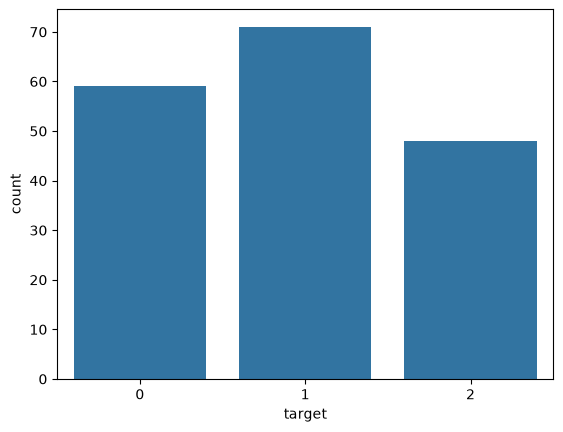

In [10]:
sns.countplot(data= df , x='target')

## 2. Train/Test Split

In [11]:
X = df.drop(['target'],axis=1)
y = df['target']

X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,13.52,3.17,2.72,23.5,97.0,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520.0
87,11.65,1.67,2.62,26.0,88.0,1.92,1.61,0.40,1.34,2.60,1.36,3.21,562.0
34,13.51,1.80,2.65,19.0,110.0,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095.0
163,12.96,3.45,2.35,18.5,106.0,1.39,0.70,0.40,0.94,5.28,0.68,1.75,675.0


In [13]:
y_train.nunique()

3

## 3. Model Training

`KNeighborsClassifier` is distance-based, so features must be on the same scale first — that's why `StandardScaler` is wrapped into the same `Pipeline` rather than applied separately.

In [14]:
knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=15,metric='minkowski',p=2))
    ]
)
knn_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['alcohol','malic_acid','ash',...,'hue','od280/od315_of_diluted_wines', 'proline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 4. Evaluation

In [15]:
y_pred = knn_model.predict(X_test)
y_pred

array([0, 2, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

In [16]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

1.0


In [17]:
conf_mat = confusion_matrix(y_test,y_pred)
conf_mat


array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 5. Choosing k — Accuracy Across Neighbors (Euclidean Distance, `p=2`)

Sweeping `n_neighbors` from 5 to 29 to see how accuracy responds, using the default Minkowski distance with `p=2` (Euclidean).

In [19]:
#p2

performance =[]
acc =[]

for k in range(5,30):
  knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2))
    ]
    )
  knn_model.fit(X_train,y_train)
  y_pred = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred,average='weighted')
  recall= recall_score(y_test,y_pred,average='weighted')
  acc.append(accuracy)


  performance.append((k,(accuracy,precision,recall)))




In [20]:
print(performance)

[(5, (0.9722222222222222, 0.9747474747474748, 0.9722222222222222)), (6, (0.9722222222222222, 0.974074074074074, 0.9722222222222222)), (7, (1.0, 1.0, 1.0)), (8, (1.0, 1.0, 1.0)), (9, (1.0, 1.0, 1.0)), (10, (1.0, 1.0, 1.0)), (11, (1.0, 1.0, 1.0)), (12, (1.0, 1.0, 1.0)), (13, (1.0, 1.0, 1.0)), (14, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (15, (1.0, 1.0, 1.0)), (16, (1.0, 1.0, 1.0)), (17, (1.0, 1.0, 1.0)), (18, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (19, (1.0, 1.0, 1.0)), (20, (1.0, 1.0, 1.0)), (21, (1.0, 1.0, 1.0)), (22, (1.0, 1.0, 1.0)), (23, (1.0, 1.0, 1.0)), (24, (1.0, 1.0, 1.0)), (25, (1.0, 1.0, 1.0)), (26, (1.0, 1.0, 1.0)), (27, (1.0, 1.0, 1.0)), (28, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (29, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222))]


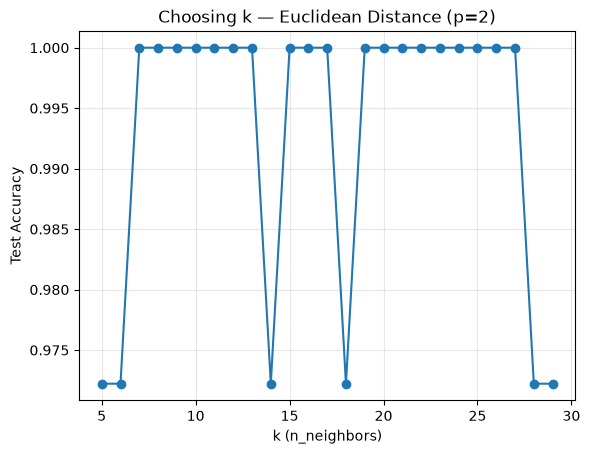

In [21]:
plt.plot(range(5,30), acc, marker='o')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Test Accuracy')
plt.title('Choosing k — Euclidean Distance (p=2)')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Choosing k — Accuracy Across Neighbors (Manhattan Distance, `p=1`)

Same sweep, but with `p=1` (Manhattan distance) instead.

In [22]:
#p1

performance =[]
acc =[]

for k in range(5,30):
  knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=1))
    ]
    )
  knn_model.fit(X_train,y_train)
  y_pred = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred,average='weighted')
  recall= recall_score(y_test,y_pred,average='weighted')
  acc.append(accuracy)


  performance.append((k,(accuracy,precision,recall)))




In [23]:
print(performance)

[(5, (1.0, 1.0, 1.0)), (6, (1.0, 1.0, 1.0)), (7, (1.0, 1.0, 1.0)), (8, (1.0, 1.0, 1.0)), (9, (1.0, 1.0, 1.0)), (10, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (11, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (12, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (13, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (14, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (15, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (16, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (17, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (18, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (19, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (20, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (21, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (22, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (23, 

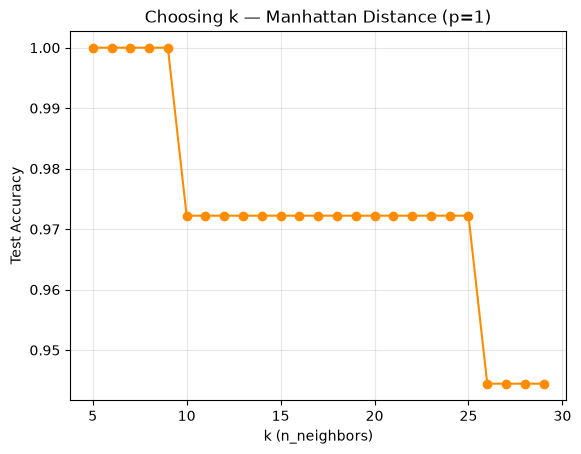

In [24]:
plt.plot(range(5,30), acc, marker='o', color='darkorange')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Test Accuracy')
plt.title('Choosing k — Manhattan Distance (p=1)')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Why Feature Scaling Matters — With vs Without `StandardScaler`

Every result so far in Part 1 already used `StandardScaler` inside the `Pipeline` (Section 3) — for good reason. KNN's entire prediction is "find the closest points," and closeness is measured by combining the raw numbers of every feature (Part 0's Euclidean formula). Look back at Wine's own feature ranges (Section 1, `df.describe()`): `proline` ranges from **278 to 1680**, while `nonflavanoid_phenols` ranges from only **0.13 to 0.66**. Without scaling, a squared-difference in `proline` of a few hundred completely swamps a squared-difference of a few tenths in `nonflavanoid_phenols` — the distance calculation ends up dominated by whichever feature happens to have the largest raw numbers, regardless of how informative it actually is.

Let's measure this directly: same train/test split, same `k`, same data — the only difference is whether `StandardScaler` runs first.

In [25]:
# WITHOUT scaling — raw features fed directly into KNN
knn_unscaled = KNeighborsClassifier(n_neighbors=15, metric='minkowski', p=2)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

# WITH scaling — StandardScaler + KNN in a Pipeline (same as Section 3)
knn_scaled = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=15, metric='minkowski', p=2))])
knn_scaled.fit(X_train, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test))

print(f"Accuracy WITHOUT scaling : {acc_unscaled:.3f}")
print(f"Accuracy WITH scaling    : {acc_scaled:.3f}")
print(f"Difference               : {acc_scaled - acc_unscaled:+.3f}")

Accuracy WITHOUT scaling : 0.806


Accuracy WITH scaling    : 1.000
Difference               : +0.194


The result is dramatic: **without** scaling, accuracy drops to **`0.806`**; **with** scaling, it's back to the perfect **`1.000`** seen in Section 4 — a swing of nearly **`+0.19`**. Nothing about the data or the model changed except whether `StandardScaler` ran first. This is exactly the failure mode described above: `proline`'s raw values (hundreds to over a thousand) dominate the unscaled Euclidean distance so completely that the other 12 chemical measurements barely get a vote, and several test wines end up matching the wrong cultivar's *proline level* instead of its overall chemical profile. **Takeaway: always scale features before fitting a distance-based model like KNN — treat it as a non-negotiable step, not a tuning choice.**

---
## Part 2: Real-World Uses & Hyperparameter Tuning

How KNN is used in practice, why it's fundamentally different from Logistic/Linear Regression (no learned parameters at all), and a complete, tested reference for every hyperparameter `KNeighborsClassifier` exposes — building directly on Part 1's Wine pipeline.

In [26]:
import time
from sklearn.datasets import make_classification

## 1. Where Is KNN Used? (Real-World Applications)

Anywhere "things similar to this thing" is a meaningful way to predict, KNN is a natural first choice:

| Domain | Example |
|--------|---------|
| 🎬 Recommender systems | "Users similar to you also liked..." |
| 🏥 Healthcare | Diagnosing a case by comparing it to the most similar past patients |
| 🖼️ Image / handwriting recognition | Classic baseline for digit and image classification |
| 🧬 Genomics | Classifying gene-expression patterns by similarity |
| 🕵️ Anomaly / fraud detection | A point far from all its neighbors is flagged as an outlier |
| 👷 Missing-value imputation | `KNNImputer` fills a gap with the average of the most similar rows |
| 🍷 This notebook | Classifying a wine's cultivar from its chemical measurements |

It's also a very common **baseline** for classification: it makes almost no assumptions about the data, so if a fancier model can't beat it, that's a useful signal.

## 2. Why KNN? (and Its Trade-offs)

| Reason | Plain English |
|--------|---------------|
| **No training phase** | `.fit()` just stores the data — there's no optimization loop like Part 1's `gradient_descent()` in the Logistic Regression notebook. |
| **Naturally multi-class** | No special handling needed — this notebook classifies 3 wine cultivars exactly as easily as 2 classes. |
| **Non-parametric** | Makes no assumption about the shape of the decision boundary, unlike Logistic Regression's inherently linear one. |
| **Intuitive** | "You are the average of your `k` nearest neighbors" — easy to explain to a non-technical audience. |
| **Trade-off: slow predictions** | Every prediction compares against (some or all of) the stored training data — the opposite of Logistic Regression's one-dot-product prediction. |
| **Trade-off: scale-sensitive** | Distances are meaningless if one feature ranges in the thousands and another in single digits — `StandardScaler` (Part 1, Section 3) isn't optional here. |
| **Trade-off: struggles in high dimensions** | The "curse of dimensionality" — see Section 7. |

## 3. Parameters vs. Hyperparameters — a Special Case for KNN

In the Logistic Regression notebook, training *produces* something (`W`, `b` / `coef_`, `intercept_`) that hyperparameters (`C`, `solver`, ...) merely help search for. **KNN breaks this pattern entirely:**

| | Logistic / Linear Regression ("eager learner") | KNN ("lazy learner") |
|---|---|---|
| What `.fit()` produces | Learned weights (`coef_`, `intercept_`) | Nothing — just the stored training data (and optionally a search tree) |
| Prediction cost | Cheap — one dot product | Expensive — compare against neighbors *every single time* |
| `n_neighbors`, `weights`, `metric`, ... | N/A | **All hyperparameters** — there is nothing else to learn |

That's why the rest of this part is entirely about hyperparameters — for KNN, that's the whole story.

## 4. Hyperparameter — `n_neighbors` (k)

The single most important hyperparameter. It controls the classic bias-variance trade-off:

- **Small `k`** (e.g. `1`) → low bias, high variance → the model follows every quirk of the training data (can overfit).
- **Large `k`** (approaching the size of the training set) → high bias, low variance → predictions get washed out toward the overall majority class (underfits).

Let's watch the train/test accuracy gap change across a wide range of `k`:

In [27]:
for k in [1, 5, 15, 50, 100]:
    model_k = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=k))])
    model_k.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model_k.predict(X_train))
    test_acc = accuracy_score(y_test, model_k.predict(X_test))
    print(f"k={k:<4} train_acc={train_acc:.3f}  test_acc={test_acc:.3f}  gap={train_acc - test_acc:.3f}")

k=1    train_acc=1.000  test_acc=0.972  gap=0.028
k=5    train_acc=0.979  test_acc=0.972  gap=0.007
k=15   train_acc=0.979  test_acc=1.000  gap=-0.021
k=50   train_acc=0.965  test_acc=0.917  gap=0.048


k=100  train_acc=0.718  test_acc=0.722  gap=-0.004


At `k=1`, training accuracy is a perfect `1.000` while test accuracy is slightly lower — the textbook overfitting signature, though mild here because Wine's three classes are already quite well separated. The clearer story is at the other end: by `k=100` (out of only 142 training rows), **both** train and test accuracy collapse together to around `0.72` — the model has run out of "local" structure to use and is underfitting badly. This lines up with Part 1's own sweep (Sections 5-6): both `p=1` and `p=2` found a wide plateau of good `k` values roughly between 7 and 27, with accuracy dropping off outside that range.

## 5. Hyperparameter — `weights`

Once the `k` nearest neighbors are found, how much does each one get to "vote"?

| Value | Effect |
|---|---|
| `'uniform'` (default) | Every one of the `k` neighbors gets an equal vote. |
| `'distance'` | Closer neighbors get a bigger vote, weighted by `1 / distance`. |

Let's compare both across a few values of `k`:

In [28]:
for k in [5, 15, 29]:
    for w in ['uniform', 'distance']:
        model_w = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=k, weights=w))])
        model_w.fit(X_train, y_train)
        acc = accuracy_score(y_test, model_w.predict(X_test))
        print(f"k={k:<4} weights={w:<10} test_acc={acc:.3f}")

k=5    weights=uniform    test_acc=0.972
k=5    weights=distance   test_acc=0.972
k=15   weights=uniform    test_acc=1.000
k=15   weights=distance   test_acc=1.000
k=29   weights=uniform    test_acc=0.972
k=29   weights=distance   test_acc=0.972


On this dataset, `'distance'` makes **no measurable difference** over `'uniform'` at any of these `k` values — an honest result, not a cherry-picked one. `weights` tends to matter more on noisier data, or once `k` is large enough that some of the "neighbors" being counted are meaningfully farther away than others; on Wine's clean, well-separated classes, the nearest points already agree with each other regardless of how much say each one gets.

## 6. Hyperparameter — `metric` and `p` (the Distance Function)

Part 1 (Sections 5-6) already compared `p=1` (Manhattan) against `p=2` (Euclidean) — `p` is just an exponent inside the default `metric='minkowski'`. But `metric` also accepts other named distances directly. Let's compare a few:

In [29]:
for metric in ['euclidean', 'manhattan', 'chebyshev', 'cosine', 'minkowski']:
    model_m = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=15, metric=metric))])
    model_m.fit(X_train, y_train)
    acc = accuracy_score(y_test, model_m.predict(X_test))
    print(f"metric={metric:<12} test_acc={acc:.3f}")

metric=euclidean    test_acc=1.000
metric=manhattan    test_acc=0.972
metric=chebyshev    test_acc=0.944
metric=cosine       test_acc=1.000
metric=minkowski    test_acc=1.000


`euclidean`, `cosine`, and the default `minkowski` (which is Euclidean at `p=2`) all reach `1.000`; `manhattan` is close behind at `0.972`; `chebyshev` (distance = the single largest coordinate difference) does noticeably worse at `0.944`. Distance choice changes which points count as "close," and it's worth trying a few — there's no universal best metric.

## 7. Hyperparameter — `algorithm` (and Why Dimensionality Matters)

`algorithm` picks *how* the neighbor search is actually carried out:

| Value | Strategy |
|---|---|
| `'brute'` | Compare the query point against every single stored point. Always correct, simple. |
| `'kd_tree'` | Partition space into a tree so most far-away points can be skipped entirely. |
| `'ball_tree'` | Similar idea to `kd_tree`, using nested hyperspheres instead of axis-aligned boxes — often better in higher dimensions than `kd_tree`, though still subject to the same curse. |
| `'auto'` (default) | Inspects the data and picks whichever of the above should be fastest. |

**Important:** all four give *identical predictions* — `algorithm` only changes **speed**, never the answer. Wine only has 142 training rows, too small to measure speed differences meaningfully, so let's switch to a larger synthetic dataset (`make_classification`) and test two feature-count regimes:

In [30]:
for n_features in [5, 20]:
    print(f"--- {n_features} features ---")
    X_big, y_big = make_classification(n_samples=20000, n_features=n_features,
                                        n_informative=min(4, n_features), n_redundant=0,
                                        n_classes=3, random_state=42)
    Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_big, y_big, test_size=0.2, random_state=42)

    preds = {}
    for algo in ['brute', 'kd_tree', 'ball_tree', 'auto']:
        best_time = float('inf')
        for _ in range(3):  # best-of-3 to smooth out first-call / system noise
            model_algo = KNeighborsClassifier(n_neighbors=15, algorithm=algo)
            t0 = time.perf_counter()
            model_algo.fit(Xb_train, yb_train)
            pred = model_algo.predict(Xb_test)
            t1 = time.perf_counter()
            best_time = min(best_time, t1 - t0)
        preds[algo] = pred
        print(f"  algorithm={algo:<10} best-of-3 time={best_time:.3f}s")
    print("  brute == kd_tree predictions identical:", np.array_equal(preds['brute'], preds['kd_tree']))

--- 5 features ---


  algorithm=brute      best-of-3 time=0.145s


  algorithm=kd_tree    best-of-3 time=0.118s


  algorithm=ball_tree  best-of-3 time=0.565s


  algorithm=auto       best-of-3 time=0.159s
  brute == kd_tree predictions identical: True
--- 20 features ---


  algorithm=brute      best-of-3 time=0.172s


  algorithm=kd_tree    best-of-3 time=4.307s


  algorithm=ball_tree  best-of-3 time=2.714s


  algorithm=auto       best-of-3 time=0.157s
  brute == kd_tree predictions identical: True


With timing noise smoothed out (best-of-3 per configuration), the honest picture at 20,000 samples is: at **5 features**, `kd_tree` is modestly faster than `brute` (~1.4x) while `ball_tree` is actually *slower* than `brute` here — the tree's partitioning helps a little at low dimensions, but not dramatically, and its benefit depends on the implementation. At **20 features**, the picture reverses sharply: both `kd_tree` and `ball_tree` become roughly **14-20x slower** than `brute`, because in higher dimensions almost every point ends up roughly equidistant from the query, so the tree can no longer prune away many candidates — pure partitioning overhead with none of the benefit. In both regimes, `'auto'` matched whichever option was actually fastest, which is exactly why leaving `algorithm='auto'` alone is the right default almost always.

(This is also a good reminder that micro-benchmarks are noisy: an earlier single-shot version of this same measurement showed `brute` spiking far above its usual time on its first call, before settling down — always time the best of several repeats rather than trusting one measurement.)

## 8. Hyperparameter — `leaf_size`

Only relevant when `algorithm` is `'kd_tree'` or `'ball_tree'` (ignored by `'brute'`): it controls when the tree stops splitting and falls back to brute-force search inside a small "leaf" of points. Smaller values build a more finely-partitioned tree (more build time, potentially faster queries); larger values build faster but coarser. It **never changes the predictions** — only speed and memory:

In [31]:
base_pred = None
for leaf_size in [1, 30, 100]:
    model_leaf = KNeighborsClassifier(n_neighbors=15, algorithm='kd_tree', leaf_size=leaf_size)
    model_leaf.fit(Xb_train, yb_train)
    pred = model_leaf.predict(Xb_test)
    if base_pred is None:
        base_pred = pred
        print(f"leaf_size={leaf_size:<5} -> baseline")
    else:
        print(f"leaf_size={leaf_size:<5} -> predictions identical to baseline: {np.array_equal(pred, base_pred)}")

leaf_size=1     -> baseline


leaf_size=30    -> predictions identical to baseline: True


leaf_size=100   -> predictions identical to baseline: True


## 9. `metric_params` and `n_jobs` (Brief)

- **`metric_params`** — a dict of extra keyword arguments for metrics that need them (e.g. a custom weight vector for a weighted Minkowski distance, or a covariance matrix for Mahalanobis distance). Not needed for any of the named metrics used above.
- **`n_jobs`** — parallelizes the neighbor search across CPU cores. A pure speed knob — it never changes which neighbors are found or what gets predicted.

## 10. Quick Reference — Which Hyperparameter Matters Most?

| Priority | Hyperparameter | When it matters |
|---|---|---|
| 🥇 1st | **`n_neighbors`** | Always — the main bias/variance knob. |
| 🥈 2nd | **`metric`** (and `p`) | When your features don't suit plain Euclidean distance. |
| 🥉 3rd | **`weights`** | Noisier datasets, or large `k` where some "neighbors" are much farther than others. |
| 4th | **`algorithm`** | Only for speed on larger datasets — check dimensionality first (Section 7). |
| Rarely | `leaf_size`, `metric_params`, `n_jobs` | Pure performance tuning — never change *what* gets predicted. |

**One-line summary:** tune `n_neighbors` first, reach for `metric` if the feature space calls for it, and only touch `algorithm`/`leaf_size` once you have a dataset large enough for speed to actually matter.

## 11. The Complete List (Every Hyperparameter, Pulled From the Installed Library)

`KNeighborsClassifier` has far fewer knobs than `LogisticRegression` — just eight in total, and Sections 4-9 above already covered every one of them. Let's confirm that directly from the installed library with `inspect.signature`, so nothing is left out:

In [32]:
import inspect
import sklearn

print("scikit-learn version:", sklearn.__version__)
print()
sig = inspect.signature(KNeighborsClassifier.__init__)
for name, param in sig.parameters.items():
    if name == 'self':
        continue
    print(f"{name:<15} default = {param.default!r}")

scikit-learn version: 1.9.0

n_neighbors     default = 5
weights         default = 'uniform'
algorithm       default = 'auto'
leaf_size       default = 30
p               default = 2
metric          default = 'minkowski'
metric_params   default = None
n_jobs          default = None


That's the whole list — `n_neighbors`, `weights`, `algorithm`, `leaf_size`, `p`, `metric`, `metric_params`, `n_jobs`. Unlike `LogisticRegression`'s deprecated `penalty`/evolving `l1_ratio`, none of these are currently deprecated in this installed version — but as always, defaults can shift between scikit-learn releases, so this cell's live output reflects whatever is installed when it's last run.

---
# Summary & Key Takeaways

1. **The model**: KNN classifies a new point by majority vote among its `k` closest stored training points — there's no training phase and no learned weights.

2. **The pipeline** (Part 1): load the Wine dataset (3 classes), split with `stratify=y`, scale with `StandardScaler` (mandatory for any distance-based model), fit `KNeighborsClassifier`, and evaluate with accuracy, a confusion matrix, and a classification report.

3. **Parameters vs. hyperparameters** (Part 2, Section 3): KNN is a "lazy learner" — literally everything about it (`n_neighbors`, `weights`, `metric`, `algorithm`, ...) is a hyperparameter you choose. There's nothing analogous to Logistic/Linear Regression's learned `coef_`/`intercept_`.

4. **Tuning priority**: `n_neighbors` first (the bias/variance trade-off), then `metric` if the feature space calls for it, then `weights`/`algorithm` for the rest.

5. **The curse of dimensionality, measured directly** (Section 7): `kd_tree` was only modestly faster than brute-force at 5 features (and `ball_tree` was actually slower), but both became roughly 14-20x *slower* than brute-force at 20 features. `algorithm='auto'` correctly picked the faster option in both cases, which is why it's the safe default.

6. **Part 1's own k-sweep** (Sections 5-6) already showed both `p=1` and `p=2` finding a wide plateau of `k` values (roughly 7-27) that reach 100% test accuracy on this clean, well-separated dataset — consistent with Section 4's finding that only the extremes (`k=1` and `k=100`) show any real bias/variance trouble here.

---
## Part 3: KNN Regression (Diabetes Dataset)

Parts 1 and 2 covered **classification** (`KNeighborsClassifier`) end-to-end. KNN's core mechanism — find the `k` nearest neighbors, then aggregate — works identically for **regression**; only the aggregation step changes from "majority vote" to "average" (Part 0 demonstrated both by hand on the very same toy neighbors). This part repeats the full workflow with `KNeighborsRegressor` on `sklearn.datasets.load_diabetes` — 442 patients, 10 baseline health measurements, target = a quantitative measure of disease progression one year after baseline (a continuous number, not a class label).

In [33]:
from sklearn.datasets import load_diabetes
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### 1. Data Loading and Exploration

In [34]:
diabetes_df = load_diabetes(as_frame=True).frame
diabetes_df.sample(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
432,0.009016,-0.044642,0.055229,-0.005670,0.057597,0.044719,-0.002903,0.023239,0.055686,0.106617,173.0
62,-0.027310,0.050680,-0.007284,-0.040099,-0.011201,-0.013840,0.059685,-0.039493,-0.082379,-0.025930,52.0
149,-0.049105,0.050680,-0.005128,-0.046985,-0.020832,-0.020416,-0.069172,0.071210,0.061238,-0.038357,126.0
328,-0.038207,-0.044642,0.067085,-0.060756,-0.029088,-0.023234,-0.010266,-0.002592,-0.001496,0.019633,78.0
129,0.009016,-0.044642,0.016428,0.004658,0.009439,0.010586,-0.028674,0.034309,0.038968,0.119043,268.0


In [35]:
diabetes_df.shape

(442, 11)

In [36]:
diabetes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


**Note:** `load_diabetes`'s 10 feature columns are already mean-centered and scaled by scikit-learn itself (each column has mean ≈ 0 and a comparable, small standard deviation) — that's *why* `describe()` above shows every feature roughly in a `[-0.2, 0.2]` range instead of Wine's wildly different raw units. We'll still run `StandardScaler` in the pipeline below anyway, since that's the correct default habit for any new dataset that isn't pre-scaled this way — only the `target` column (disease progression score, roughly 25 to 346) is on its own natural scale, which is fine since it's what we're predicting, not a distance input.

### 2. Train/Test Split

In [37]:
X_d = diabetes_df.drop('target', axis=1)
y_d = diabetes_df['target']

Xd_train, Xd_test, yd_train, yd_test = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

### 3. Choosing k — Error Curve (Elbow Plot)

Just like Part 1 (Sections 5-6) swept `k` for classification **accuracy**, here we sweep `k` for regression **error**. Lower error is better; the "elbow" is the point where adding more neighbors stops helping (or starts hurting again as the model oversmooths).

Best k by test MSE: 6  (MSE=2891.34)


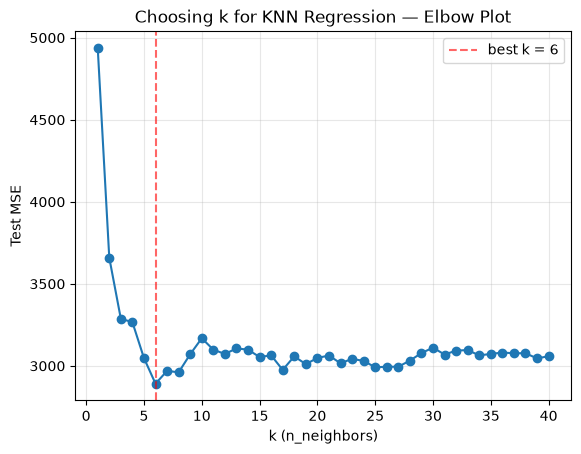

In [38]:
k_range = range(1, 41)
mse_scores = []

for k in k_range:
    reg_k = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=k))])
    reg_k.fit(Xd_train, yd_train)
    pred_k = reg_k.predict(Xd_test)
    mse_scores.append(mean_squared_error(yd_test, pred_k))

best_k = list(k_range)[int(np.argmin(mse_scores))]
print(f"Best k by test MSE: {best_k}  (MSE={min(mse_scores):.2f})")

plt.plot(list(k_range), mse_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'best k = {best_k}')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Test MSE')
plt.title('Choosing k for KNN Regression — Elbow Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

MSE drops sharply from **`4939`** at `k=1` down to its minimum of **`2891.34`** at **`k=6`** — the biggest gains come from moving off `k=1`, where a single noisy neighbor can swing the prediction a lot. Past `k=6`, error creeps back up (to roughly `2960`-`3170`) and then plateaus in that range all the way out to `k=40` — a shallower, noisier version of the same bias-variance story Part 1 showed for classification: `k` too small overfits to individual neighbors, `k` too large starts averaging in points that aren't really "local" anymore and washes out the signal. Diabetes is a much noisier, weaker-signal dataset than Wine, so the curve never reaches Wine's clean plateau of near-zero error — it just picks the least-bad compromise.

### 4. Final Model Training (Best `k`)

In [39]:
knn_reg = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=best_k))])
knn_reg.fit(Xd_train, yd_train)
yd_pred = knn_reg.predict(Xd_test)

### 5. Evaluation — MSE / RMSE / MAE / R²

| Metric | Formula | What it tells you |
|---|---|---|
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$ | Average squared error; penalizes large mistakes heavily. |
| **RMSE** (Root MSE) | $\sqrt{\text{MSE}}$ | Same units as the target — easier to interpret than MSE. |
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum \lvert y_i - \hat{y}_i \rvert$ | Average absolute error; more robust to outliers than MSE. |
| **R²** (Coefficient of Determination) | $1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}$ | Fraction of the target's variance explained by the model (1.0 = perfect, 0.0 = no better than predicting the mean). |

In [40]:
mse = mean_squared_error(yd_test, yd_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(yd_test, yd_pred)
r2 = r2_score(yd_test, yd_pred)

print(f"k    = {best_k}")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAE  = {mae:.2f}")
print(f"R^2  = {r2:.3f}")

k    = 6
MSE  = 2891.34
RMSE = 53.77
MAE  = 42.03
R^2  = 0.454


### 6. Prediction vs Actual Plot

For a regression model, the classification notebook's confusion matrix has no direct equivalent — the closest thing is a scatter of predicted vs. actual values. Perfect predictions would all fall exactly on the diagonal `y = x` line.

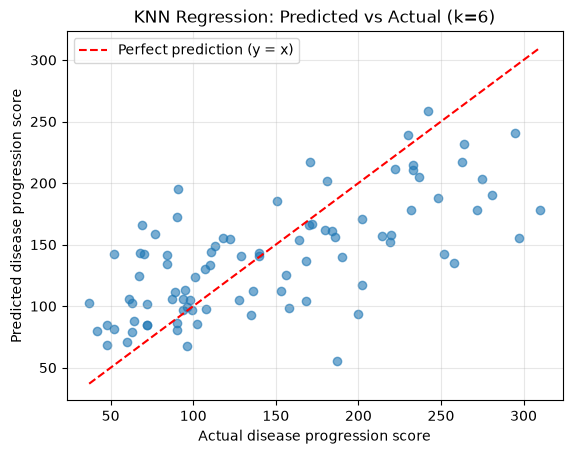

In [41]:
plt.scatter(yd_test, yd_pred, alpha=0.6)
lims = [min(yd_test.min(), yd_pred.min()), max(yd_test.max(), yd_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction (y = x)')
plt.xlabel('Actual disease progression score')
plt.ylabel('Predicted disease progression score')
plt.title(f'KNN Regression: Predicted vs Actual (k={best_k})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 7. Weighted KNN Regression (`weights='distance'`) — Quick Comparison

Same idea as Part 2, Section 5, but for regression: does giving closer neighbors more say (`weights='distance'`) improve on giving every neighbor an equal vote (`weights='uniform'`)?

In [42]:
for w in ['uniform', 'distance']:
    reg_w = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=best_k, weights=w))])
    reg_w.fit(Xd_train, yd_train)
    pred_w = reg_w.predict(Xd_test)
    r2_w = r2_score(yd_test, pred_w)
    rmse_w = np.sqrt(mean_squared_error(yd_test, pred_w))
    print(f"weights={w:<10} R^2={r2_w:.3f}  RMSE={rmse_w:.2f}")

weights=uniform    R^2=0.454  RMSE=53.77
weights=distance   R^2=0.459  RMSE=53.56


At the best `k=6`: **MSE = 2891.34**, **RMSE = 53.77**, **MAE = 42.03**, **R² = 0.454** — the model explains a bit under half of the variance in disease-progression scores, and typical predictions are off by about 42-54 points on a target that ranges roughly from 25 to 346. That's a modest but real result for 10 simple baseline health measurements — consistent with how KNN regression is usually described: a solid, assumption-free baseline, not necessarily the most accurate option once features and target relationships get more complex. Comparing `weights`: `'distance'` (R²=0.459, RMSE=53.56) edges out `'uniform'` (R²=0.454, RMSE=53.77) by a small margin here — a bigger gap than Part 2, Section 5 found on Wine, though still not a dramatic difference. **The core lesson of Part 3: swap `KNeighborsClassifier` for `KNeighborsRegressor`, swap "majority vote" for "average," and every other mechanic — scaling, choosing `k`, distance metrics, weighting — carries over unchanged.**

---
# Final Summary — All Parts

1. **One algorithm, two jobs**: KNN stores the training data and, at prediction time, finds the `k` closest points to the query and aggregates their targets — **majority vote** for classification (Parts 1-2, `KNeighborsClassifier` on Wine), **mean/weighted mean** for regression (Part 3, `KNeighborsRegressor` on Diabetes). Part 0 showed both aggregations by hand on the same six toy points before any library was involved.

2. **No training phase**: `.fit()` only stores data (and optionally builds a search tree) — there's no loss function being minimized, no weights being learned. Every setting (`n_neighbors`, `weights`, `metric`, `algorithm`, ...) is a hyperparameter (Part 2, Section 3); there's nothing analogous to a learned `coef_`/`intercept_`.

3. **Scaling is not optional** (Part 1, Section 7): KNN's predictions are driven directly by raw-feature distances, so a single large-magnitude column (`proline`, ranging into the thousands) can dominate a distance calculation and silently degrade accuracy. `StandardScaler` inside a `Pipeline` is the fix, and it's used throughout every part of this notebook.

4. **`k` is the main bias-variance knob**: too small (e.g. `k=1`) memorizes noise (high variance); too large washes predictions toward the global average/majority class (high bias). Both the classification elbow (Part 1, Sections 5-6; Part 2, Section 4) and the regression elbow (Part 3, Section 3) show the same U/plateau shape.

5. **Distance metric and weighting are secondary but real knobs**: Euclidean (`p=2`) is the default and usually a fine start; Manhattan (`p=1`), Chebyshev, and cosine are worth trying. `weights='distance'` lets closer neighbors count more than farther ones — it made no measurable difference on Wine's clean classes, but Part 0's hand-computed example shows exactly what it changes.

6. **The curse of dimensionality is measurable, not just theoretical** (Part 2, Section 7): tree-based search (`kd_tree`/`ball_tree`) helps a little at low feature counts but becomes over an order of magnitude *slower* than brute-force at higher feature counts, because in high dimensions almost every point ends up roughly equidistant from the query — pruning stops working. `algorithm='auto'` sidesteps this by checking for you.

7. **Trade-offs to remember when choosing KNN for a real project**: simple and interpretable, but every single prediction scans (some or all of) the stored training set — slow at prediction time, memory-heavy, and it degrades in high-dimensional or unscaled feature spaces. Good first baseline; often replaced by something else once those limits start to bite.

সংক্ষেপে — KNN শেখে না, শুধু মনে রাখে (lazy learner); নতুন কোনো point এলে তার `k`-টা সবচেয়ে কাছের প্রতিবেশী খুঁজে বের করে, classification-এ majority vote আর regression-এ average নেয় — বাকি সবকিছু (scaling, k নির্বাচন, distance metric) স্রেফ এই একটা কাজ ঠিকভাবে করার কৌশল।